In [42]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import Point, LineString, Polygon, MultiPoint, mapping
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
import plotly.express as px

In [2]:
# for the langoid CSV file 
df = pd.read_csv("glottolog_languoid.csv/languoid.csv") 
df.head() 

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [3]:
df = pd.read_csv("dravidian-mother-tongues-main-n-level.csv")
df = df.dropna()
df

,Mother tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,Malayalam,34776533,16681977,18094556,17355542,8339365,9016177,17420991,8342612,9078379
1,Tamil,68888839,34531580,34357259,35530671,17829882,17700789,33358168,16701698,16656470
2,Telugu,80912459,40549767,40362692,53738513,26918237,26820276,27173946,13631530,13542416
3,Kannada,43506272,22014001,21492271,30614889,15462374,15152515,12891383,6551627,6339756
4,Tulu,1841963,899059,942904,1081821,525977,555844,760142,373082,387060


In [4]:
df.columns

Index(['Mother tongue', 'Total_P', 'Total_M', 'Total_F', 'Rural_P', 'Rural_M',
       'Rural_F', 'Urban_P', 'Urban_M', 'Urban_F'],
      dtype='str')

In [5]:
### Nation-level Plotting

In [6]:
### Total Mother Tongue Speakers

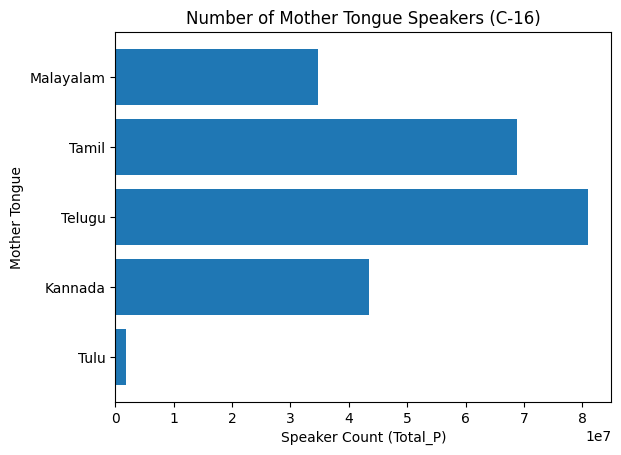

In [7]:
fig, ax = plt.subplots()

# Example data
ax.barh(
    df["Mother tongue"],
    df["Total_P"]
)
ax.set_ylabel("Mother Tongue")
ax.set_xlabel("Speaker Count (Total_P)")
ax.set_title("Number of Mother Tongue Speakers (C-16)")
ax.invert_yaxis()

plt.show()

In [8]:
# for the langoid CSV file 
df = pd.read_csv("glottolog_languoid.csv/languoid.csv") 
df.head() 

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [9]:
df.columns

Index(['id', 'family_id', 'parent_id', 'name', 'bookkeeping', 'level',
       'latitude', 'longitude', 'iso639P3code', 'description',
       'markup_description', 'child_family_count', 'child_language_count',
       'child_dialect_count', 'country_ids'],
      dtype='str')

In [10]:
tamil = df[df["name"] == "Tamil"]
tamil

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
22917,tami1289,drav1251,tami1300,Tamil,False,language,10.520219,78.825989,tam,NaN,NaN,0,0,18,IN LK


In [11]:
malayalam = df[df["name"] == "Malayalam"]
malayalam

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
13316,mala1464,drav1251,mala1541,Malayalam,False,language,9.59208,76.7651,mal,NaN,NaN,0,0,13,IN


In [12]:
tamil_longitude_val = tamil["longitude"].iloc[0]
tamil_latitude_val = tamil["latitude"].iloc[0]
# created a geometric object in coordinate space 
tamil_point = Point(tamil_longitude_val, tamil_latitude_val)

In [13]:
type(tamil_point)

shapely.geometry.point.Point

In [14]:
## need to put the point into a geodataframe 
tamil_gdf = gpd.GeoDataFrame(
    {
        "name": ["Tamil"],
        "iso": ["tam"],
        "geometry": [tamil_point]
    },
    crs="EPSG:4326"
)

In [15]:
### NOW TO GET A POLYGON LAYER (INDIA) 
india_states = gpd.read_file("gadm41_IND_shp/gadm41_IND_1.shp") 
india_states.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,NA,"MULTIPOLYGON (((93.79078 6.85139, 93.79092 6.8..."
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,IN-AP,"MULTIPOLYGON (((78.73952 13.04549, 78.73218 13..."
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,IN-AR,"POLYGON ((95.3683 27.10736, 95.37366 27.108, 9..."
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,NA,"POLYGON ((94.19125 27.49632, 94.1869 27.49081,..."
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,IN-AS,"POLYGON ((92.7545 24.50112, 92.75133 24.49437,..."


## State Level Plotting

In [16]:
### State Level Graphs
state_df = pd.read_csv("dravidian-mother-tongues-main-state-level.csv")
state_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,Kerala,Malayalam,32393324,15482417,16910907,16848670,8082073,8766597,15544654,7400344,8144310
1,Karnataka,Malayalam,745903,374572,371331,312494,155400,157094,433409,219172,214237
2,Tamil Nadu,Malayalam,718977,347788,371189,104745,51089,53656,614232,296699,317533
3,Maharashtra,Malayalam,365140,187005,178135,14444,7890,6554,350696,179115,171581
4,NCT of Delhi,Malayalam,87718,44258,43460,147,68,79,87571,44190,43381
...,...,...,...,...,...,...,...,...,...,...,...
131,Puducherry,Kannada,1768,861,907,159,82,77,1609,779,830
132,Daman & Diu,Kannada,432,259,173,44,30,14,388,229,159
133,Dadra & Nagar Haveli,Kannada,875,477,398,64,43,21,811,434,377
134,Chandigarh,Kannada,418,275,143,0,0,0,418,275,143


In [17]:
india_states["NAME_1"].unique()

<StringArray>
[   'Andaman and Nicobar',         'Andhra Pradesh',      'Arunachal Pradesh',
                  'Assam',                  'Bihar',             'Chandigarh',
           'Chhattisgarh', 'Dadra and Nagar Haveli',          'Daman and Diu',
                    'Goa',                'Gujarat',                'Haryana',
       'Himachal Pradesh',      'Jammu and Kashmir',              'Jharkhand',
              'Karnataka',                 'Kerala',            'Lakshadweep',
         'Madhya Pradesh',            'Maharashtra',                'Manipur',
              'Meghalaya',                'Mizoram',               'Nagaland',
           'NCT of Delhi',                 'Odisha',             'Puducherry',
                 'Punjab',              'Rajasthan',                 'Sikkim',
             'Tamil Nadu',              'Telangana',                'Tripura',
          'Uttar Pradesh',            'Uttarakhand',            'West Bengal']
Length: 36, dtype: str

In [18]:
india_states[["NAME_1", "geometry"]].head()

,NAME_1,geometry
0,Andaman and Nicobar,"MULTIPOLYGON (((93.79078 6.85139, 93.79092 6.8..."
1,Andhra Pradesh,"MULTIPOLYGON (((78.73952 13.04549, 78.73218 13..."
2,Arunachal Pradesh,"POLYGON ((95.3683 27.10736, 95.37366 27.108, 9..."
3,Arunachal Pradesh,"POLYGON ((94.19125 27.49632, 94.1869 27.49081,..."
4,Assam,"POLYGON ((92.7545 24.50112, 92.75133 24.49437,..."


### Malayalam 

In [19]:
malayalam_df = state_df[state_df["Mother Tongue"] == "Malayalam"]
malayalam_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,Kerala,Malayalam,32393324,15482417,16910907,16848670,8082073,8766597,15544654,7400344,8144310
1,Karnataka,Malayalam,745903,374572,371331,312494,155400,157094,433409,219172,214237
2,Tamil Nadu,Malayalam,718977,347788,371189,104745,51089,53656,614232,296699,317533
3,Maharashtra,Malayalam,365140,187005,178135,14444,7890,6554,350696,179115,171581
4,NCT of Delhi,Malayalam,87718,44258,43460,147,68,79,87571,44190,43381
5,Andhra Pradesh,Malayalam,61108,29648,31460,8378,3814,4564,52730,25834,26896
6,Goa,Malayalam,12975,7146,5829,1778,959,819,11197,6187,5010
7,Gujarat,Malayalam,64969,34194,30775,3965,2347,1618,61004,31847,29157
8,Rajasthan,Malayalam,22707,11948,10759,5266,2909,2357,17441,9039,8402
9,Chhatisgarh,Malayalam,23365,11731,11634,1510,813,697,21855,10918,10937


In [20]:
## Plotting Total_P on Choropleth map

In [21]:
## Merging Malayalam data with india_states 
mal_map = india_states.merge(malayalam_df, left_on="NAME_1", right_on="State_UT", how="left")
mal_map.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,...,Malayalam,61108.0,29648.0,31460.0,8378.0,3814.0,4564.0,52730.0,25834.0,26896.0
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,Malayalam,4012.0,2673.0,1339.0,1552.0,1148.0,404.0,2460.0,1525.0,935.0
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,Malayalam,4012.0,2673.0,1339.0,1552.0,1148.0,404.0,2460.0,1525.0,935.0
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,...,Malayalam,5759.0,3937.0,1822.0,3837.0,2797.0,1040.0,1922.0,1140.0,782.0


In [22]:
mal_map[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Malayalam,61108.0
2,Arunachal Pradesh,Malayalam,4012.0
3,Arunachal Pradesh,Malayalam,4012.0
4,Assam,Malayalam,5759.0
5,Bihar,Malayalam,899.0
6,Chandigarh,Malayalam,2168.0
10,Goa,Malayalam,12975.0
11,Gujarat,Malayalam,64969.0
12,Haryana,Malayalam,14357.0
13,Himachal Pradesh,Malayalam,1204.0


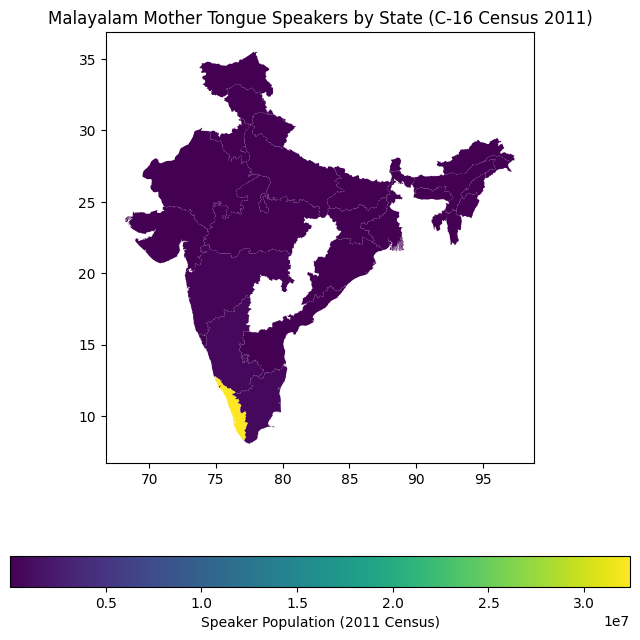

In [23]:
fig, ax = plt.subplots(figsize=(8,8))

mal_map.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Malayalam Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [44]:
## Not Including Kerala 

mal_map_outside = mal_map[mal_map["NAME_1"] != "Kerala"]
mal_map_outside[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Malayalam,61108.0
2,Arunachal Pradesh,Malayalam,4012.0
3,Arunachal Pradesh,Malayalam,4012.0
4,Assam,Malayalam,5759.0
5,Bihar,Malayalam,899.0
6,Chandigarh,Malayalam,2168.0
10,Goa,Malayalam,12975.0
11,Gujarat,Malayalam,64969.0
12,Haryana,Malayalam,14357.0
13,Himachal Pradesh,Malayalam,1204.0


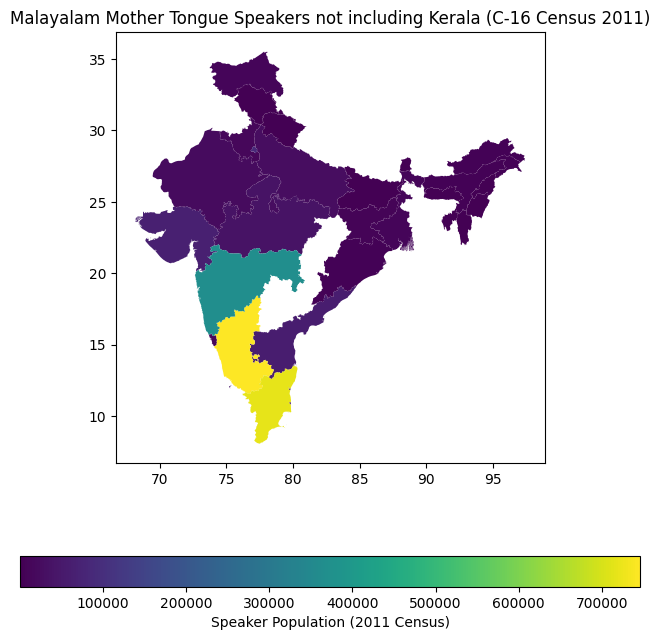

In [46]:
fig, ax = plt.subplots(figsize=(8,8))

mal_map_outside.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Malayalam Mother Tongue Speakers not including Kerala (C-16 Census 2011)", 
    fontsize=12
);

### Tamil 

In [24]:
tamil_df = state_df[state_df["Mother Tongue"] == "Tamil"]
tamil_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
34,Kerala,Tamil,498938,257186,241752,342679,174405,168274,156259,82781,73478
35,Karnataka,Tamil,2101032,1062389,1038643,328485,167600,160885,1772547,894789,877758
36,Tamil Nadu,Tamil,63743847,31913539,31830308,34087554,17096202,16991352,29656293,14817337,14838956
37,Maharashtra,Tamil,484726,250731,233995,11104,6154,4950,473622,244577,229045
38,NCT of Delhi,Tamil,82665,42661,40004,106,62,44,82559,42599,39960
39,Andhra Pradesh,Tamil,625546,313271,312275,318459,158772,159687,307087,154499,152588
40,Goa,Tamil,6939,3926,3013,1284,655,629,5655,3271,2384
41,Gujarat,Tamil,39763,21576,18187,2449,1460,989,37314,20116,17198
42,Rajasthan,Tamil,3905,2451,1454,1291,830,461,2614,1621,993
43,Chhatisgarh,Tamil,10284,5584,4700,1261,834,427,9023,4750,4273


In [25]:
## Plotting Total_P on Choropleth map
## Merging Tamil data with india_states 
tamil_map = india_states.merge(tamil_df, left_on="NAME_1", right_on="State_UT", how="left")
tamil_map.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,...,Tamil,625546.0,313271.0,312275.0,318459.0,158772.0,159687.0,307087.0,154499.0,152588.0
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,Tamil,1245.0,1050.0,195.0,814.0,708.0,106.0,431.0,342.0,89.0
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,Tamil,1245.0,1050.0,195.0,814.0,708.0,106.0,431.0,342.0,89.0
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,...,Tamil,5196.0,4218.0,978.0,3719.0,3208.0,511.0,1477.0,1010.0,467.0


In [26]:
tamil_map[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Tamil,625546.0
2,Arunachal Pradesh,Tamil,1245.0
3,Arunachal Pradesh,Tamil,1245.0
4,Assam,Tamil,5196.0
5,Bihar,Tamil,975.0
6,Chandigarh,Tamil,5579.0
10,Goa,Tamil,6939.0
11,Gujarat,Tamil,39763.0
12,Haryana,Tamil,12657.0
13,Himachal Pradesh,Tamil,1037.0


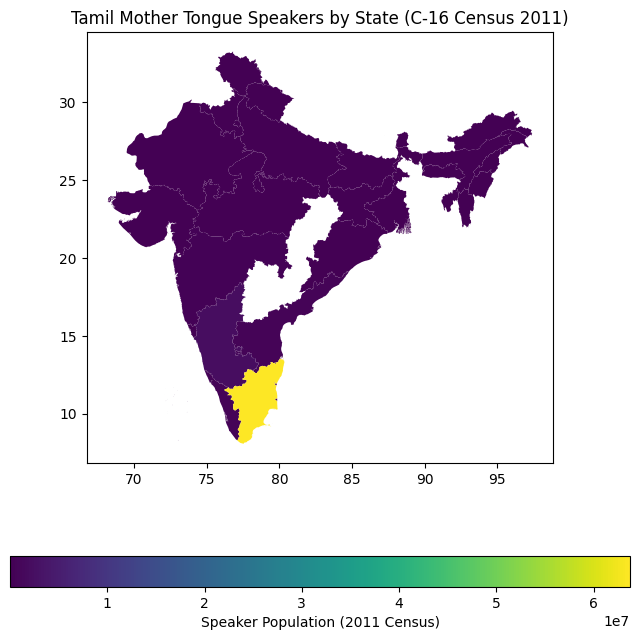

In [27]:
fig, ax = plt.subplots(figsize=(8,8))

tamil_map.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Tamil Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [55]:
## Not including Tamil Nadu


tam_map_outside = tamil_map[tamil_map["NAME_1"] != "Tamil Nadu"]
tam_map_outside[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Tamil,625546.0
2,Arunachal Pradesh,Tamil,1245.0
3,Arunachal Pradesh,Tamil,1245.0
4,Assam,Tamil,5196.0
5,Bihar,Tamil,975.0
6,Chandigarh,Tamil,5579.0
10,Goa,Tamil,6939.0
11,Gujarat,Tamil,39763.0
12,Haryana,Tamil,12657.0
13,Himachal Pradesh,Tamil,1037.0


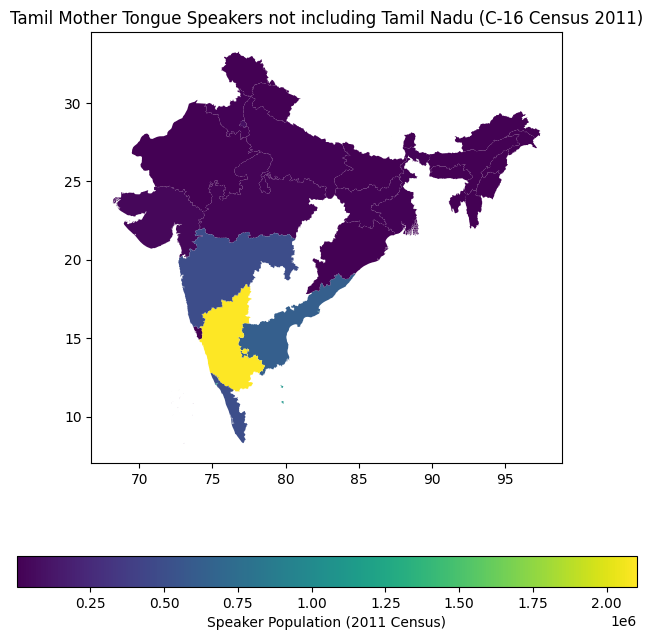

In [56]:
fig, ax = plt.subplots(figsize=(8,8))

tam_map_outside.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Tamil Mother Tongue Speakers not including Tamil Nadu (C-16 Census 2011)", 
    fontsize=12
);

In [28]:
### Telugu 

In [29]:
telugu_df = state_df[state_df["Mother Tongue"] == "Telugu"]
telugu_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
68,Kerala,Telugu,50394,26208,24186,17431,9055,8376,32963,17153,15810
69,Karnataka,Telugu,3565618,1796969,1768649,1616012,808160,807852,1949606,988809,960797
70,Tamil Nadu,Telugu,4234216,2117945,2116271,1973842,991195,982647,2260374,1126750,1133624
71,Maharashtra,Telugu,1118694,568180,550514,311977,157266,154711,806717,410914,395803
72,NCT of Delhi,Telugu,25882,13682,12200,105,51,54,25777,13631,12146
73,Andhra Pradesh,Telugu,70662838,35382930,35279908,49347283,24714317,24632966,21315555,10668613,10646942
74,Goa,Telugu,10954,6007,4947,2221,1133,1088,8733,4874,3859
75,Gujarat,Telugu,72305,38686,33619,3869,2237,1632,68436,36449,31987
76,Rajasthan,Telugu,8298,5263,3035,2521,1641,880,5777,3622,2155
77,Chhatisgarh,Telugu,1332,789,543,22,10,12,1310,779,531


In [30]:
## Plotting Total_P on Choropleth map
## Merging Telugu data with india_states 
telugu_map = india_states.merge(telugu_df, left_on="NAME_1", right_on="State_UT", how="left")
telugu_map.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,...,Telugu,70662838.0,35382930.0,35279908.0,49347283.0,24714317.0,24632966.0,21315555.0,10668613.0,10646942.0
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,Telugu,1632.0,1204.0,428.0,936.0,729.0,207.0,696.0,475.0,221.0
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,Telugu,1632.0,1204.0,428.0,936.0,729.0,207.0,696.0,475.0,221.0
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,...,Telugu,26539.0,14591.0,11948.0,11777.0,7092.0,4685.0,14762.0,7499.0,7263.0


In [31]:
telugu_map[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Telugu,70662838.0
2,Arunachal Pradesh,Telugu,1632.0
3,Arunachal Pradesh,Telugu,1632.0
4,Assam,Telugu,26539.0
5,Bihar,Telugu,1212.0
6,Chandigarh,Telugu,1332.0
10,Goa,Telugu,10954.0
11,Gujarat,Telugu,72305.0
12,Haryana,Telugu,9665.0
13,Himachal Pradesh,Telugu,1362.0


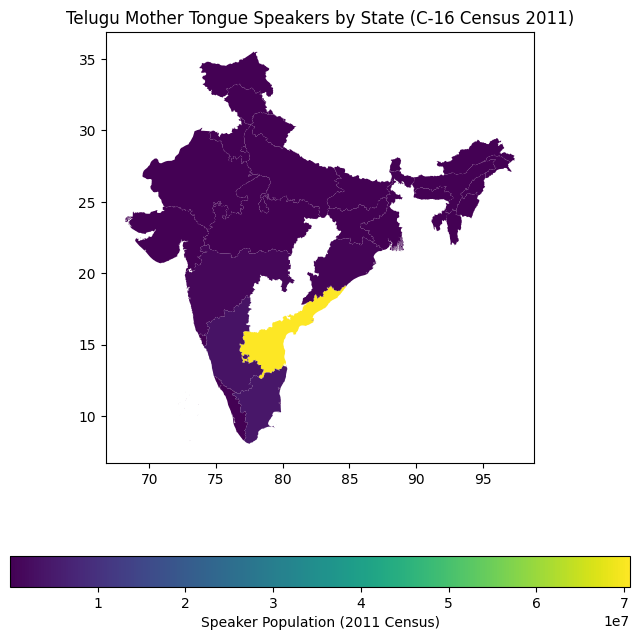

In [32]:
fig, ax = plt.subplots(figsize=(8,8))

telugu_map.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Telugu Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [57]:
### Not including Andhra Pradesh


telugu_map_outside = telugu_map[telugu_map["NAME_1"] != "Andhra Pradesh"]
telugu_map_outside[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
2,Arunachal Pradesh,Telugu,1632.0
3,Arunachal Pradesh,Telugu,1632.0
4,Assam,Telugu,26539.0
5,Bihar,Telugu,1212.0
6,Chandigarh,Telugu,1332.0
10,Goa,Telugu,10954.0
11,Gujarat,Telugu,72305.0
12,Haryana,Telugu,9665.0
13,Himachal Pradesh,Telugu,1362.0
14,Himachal Pradesh,Telugu,1362.0


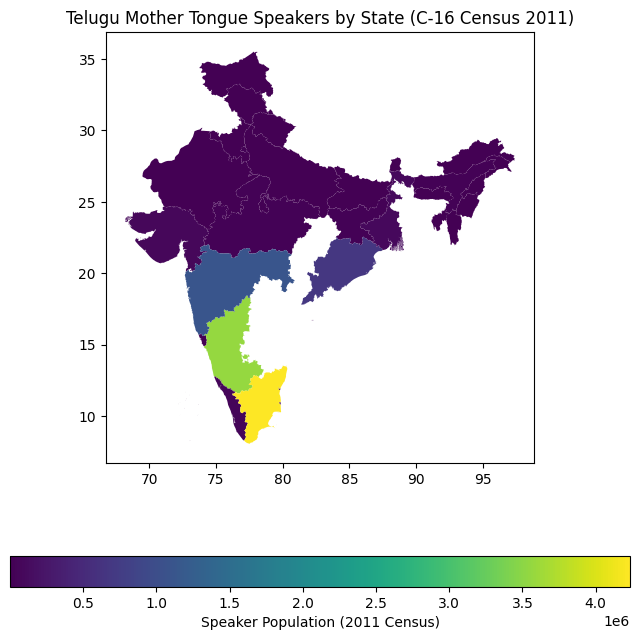

In [58]:
fig, ax = plt.subplots(figsize=(8,8))

telugu_map_outside.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Telugu Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [33]:
### Kannada 

In [34]:
kannada_df = state_df[state_df["Mother Tongue"] == "Kannada"]
kannada_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
102,Kerala,Kannada,78067,39578,38489,49503,25000,24503,28564,14578,13986
103,Karnataka,Kannada,40622836,20552989,20069847,29019265,14659315,14359950,11603571,5893674,5709897
104,Tamil Nadu,Kannada,1141976,572296,569680,606611,305561,301050,535365,266735,268630
105,Maharashtra,Kannada,993133,509115,484018,509508,260221,249287,483625,248894,234731
106,NCT of Delhi,Kannada,9261,4960,4301,17,9,8,9244,4951,4293
107,Andhra Pradesh,Kannada,532937,259988,272949,399006,192834,206172,133931,67154,66777
108,Goa,Kannada,67837,35648,32189,13926,7332,6594,53911,28316,25595
109,Gujarat,Kannada,16713,8918,7795,1333,755,578,15380,8163,7217
110,Rajasthan,Kannada,3905,2451,1454,1291,830,461,2614,1621,993
111,Chhatisgarh,Kannada,418,275,143,0,0,0,418,275,143


In [35]:
## Plotting Total_P on Choropleth map
## Merging Telugu data with india_states 
kannada_map = india_states.merge(kannada_df, left_on="NAME_1", right_on="State_UT", how="left")
kannada_map.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,...,Kannada,532937.0,259988.0,272949.0,399006.0,192834.0,206172.0,133931.0,67154.0,66777.0
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,Kannada,520.0,456.0,64.0,304.0,268.0,36.0,216.0,188.0,28.0
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,Kannada,520.0,456.0,64.0,304.0,268.0,36.0,216.0,188.0,28.0
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,...,Kannada,2356.0,1885.0,471.0,1933.0,1587.0,346.0,423.0,298.0,125.0


In [36]:
kannada_map[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Kannada,532937.0
2,Arunachal Pradesh,Kannada,520.0
3,Arunachal Pradesh,Kannada,520.0
4,Assam,Kannada,2356.0
5,Bihar,Kannada,226.0
6,Chandigarh,Kannada,418.0
10,Goa,Kannada,67837.0
11,Gujarat,Kannada,16713.0
12,Haryana,Kannada,3008.0
13,Himachal Pradesh,Kannada,457.0


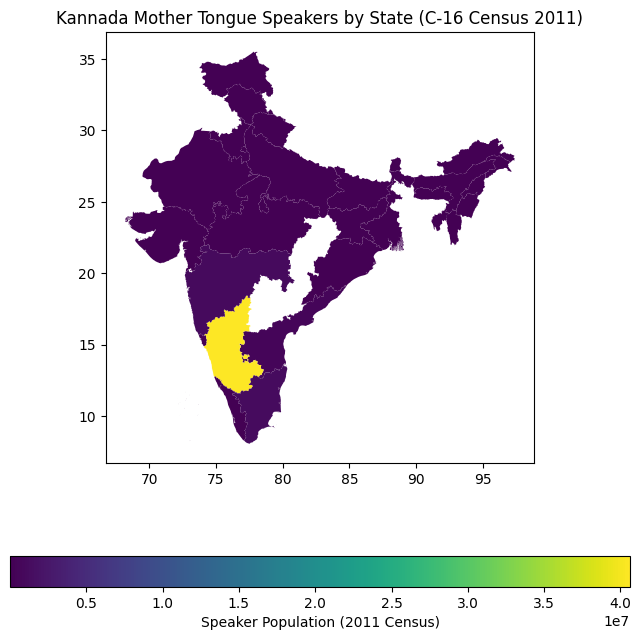

In [37]:
fig, ax = plt.subplots(figsize=(8,8))

kannada_map.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Kannada Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [59]:
## Not including Karntaka

kannada_map_outside = kannada_map[kannada_map["NAME_1"] != "Karnataka"]
kannada_map_outside[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Kannada,532937.0
2,Arunachal Pradesh,Kannada,520.0
3,Arunachal Pradesh,Kannada,520.0
4,Assam,Kannada,2356.0
5,Bihar,Kannada,226.0
6,Chandigarh,Kannada,418.0
10,Goa,Kannada,67837.0
11,Gujarat,Kannada,16713.0
12,Haryana,Kannada,3008.0
13,Himachal Pradesh,Kannada,457.0


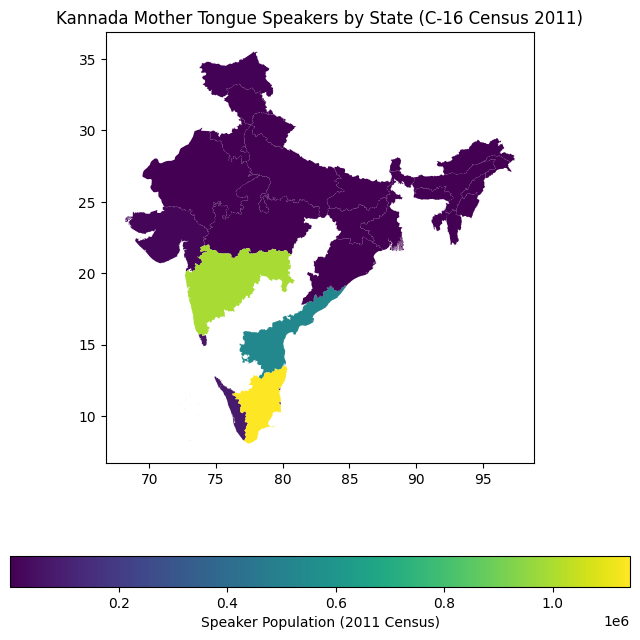

In [61]:
fig, ax = plt.subplots(figsize=(8,8))

kannada_map_outside.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Kannada Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [62]:
### Making a Multiples Map Layout of Language Distributions that include the state of origin of language

In [75]:
all_maps = [mal_map, tamil_map, kannada_map, telugu_map]

In [76]:
titles = ["Malayalam", "Telugu", "Kannada", "Telugu"]

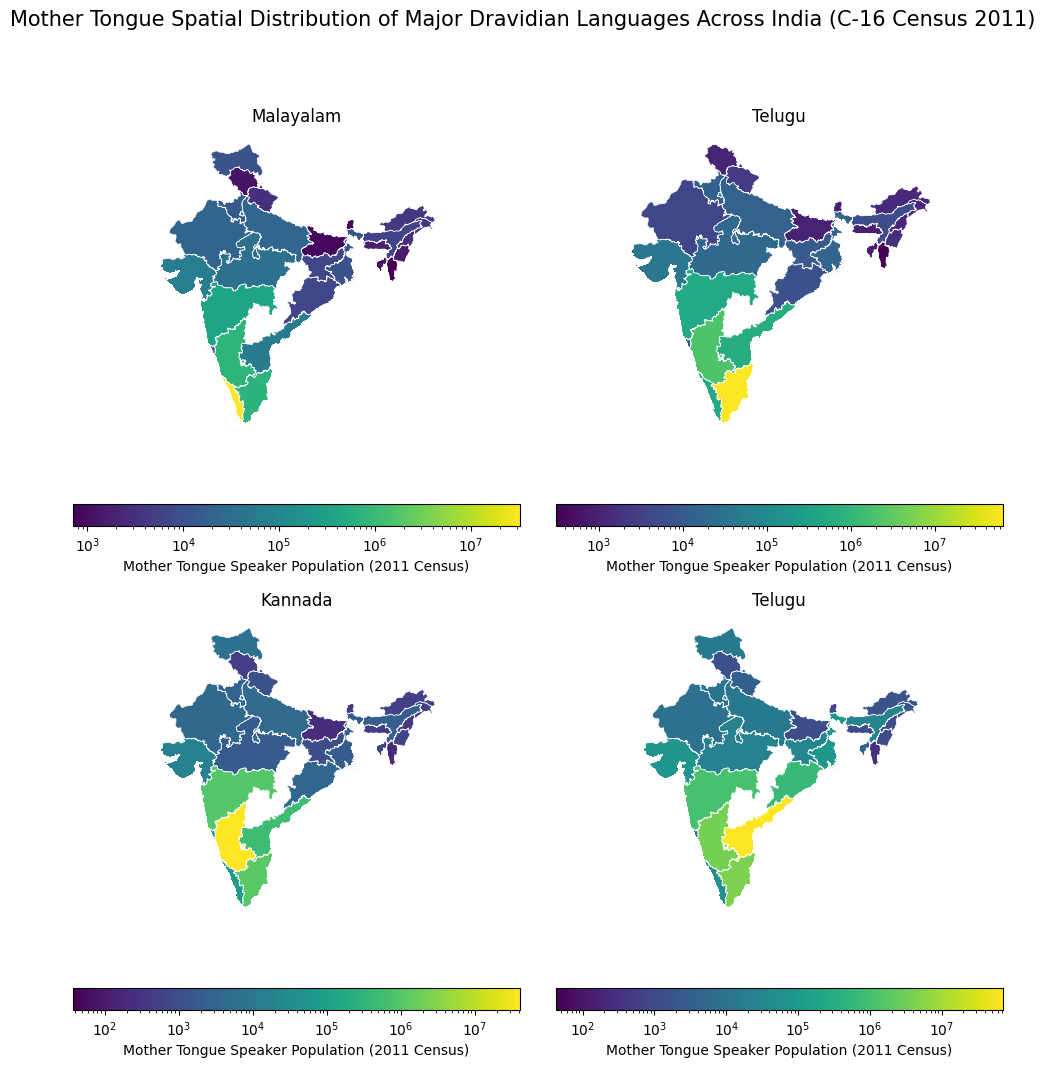

In [77]:
fig, ax = plt.subplots(2, 2, figsize=(12,12))

for map_data, title, subplot in zip(all_maps, titles, ax.flatten()):
    
    map_data.plot(
        ax=subplot,
        column="Total_P",
        norm=LogNorm(),
        legend=True, 
        edgecolor="white",
        linewidth=0.5,
        legend_kwds={"label": "Mother Tongue Speaker Population (2011 Census)", "orientation": "horizontal"}
    
    );
    
    subplot.set_title(title);
    subplot.axis('off')

#print(type(graph))

fig.subplots_adjust(wspace=0.08, hspace=0.1)
fig.suptitle("Mother Tongue Spatial Distribution of Major Dravidian Languages Across India (C-16 Census 2011)", fontsize=15);

## adding a visual gradient

#cmap = cm.viridis
#cax = ax.

# add a ScalarMappable object 
#sm = cm.ScalarMappable(cmap=cmap)
#cbar = fig.colorbar(sm, orientation="horizontal", ax=ax, pad=0.05, ticks=None);
#cbar.set_ticks([0, 1], labels=['Low Concentration', 'High Concentration'])

#colorizer = mpl.colors.(cmap='viridis')

In [63]:
### Making a Multiples Map Layout of Language Distributions that do NOT include the state of origin of language

In [72]:
all_outside_maps = [mal_map_outside, tam_map_outside, telugu_map_outside, kannada_map_outside]

In [73]:
titles = ["Malayalam", "Telugu", "Kannada", "Telugu"]

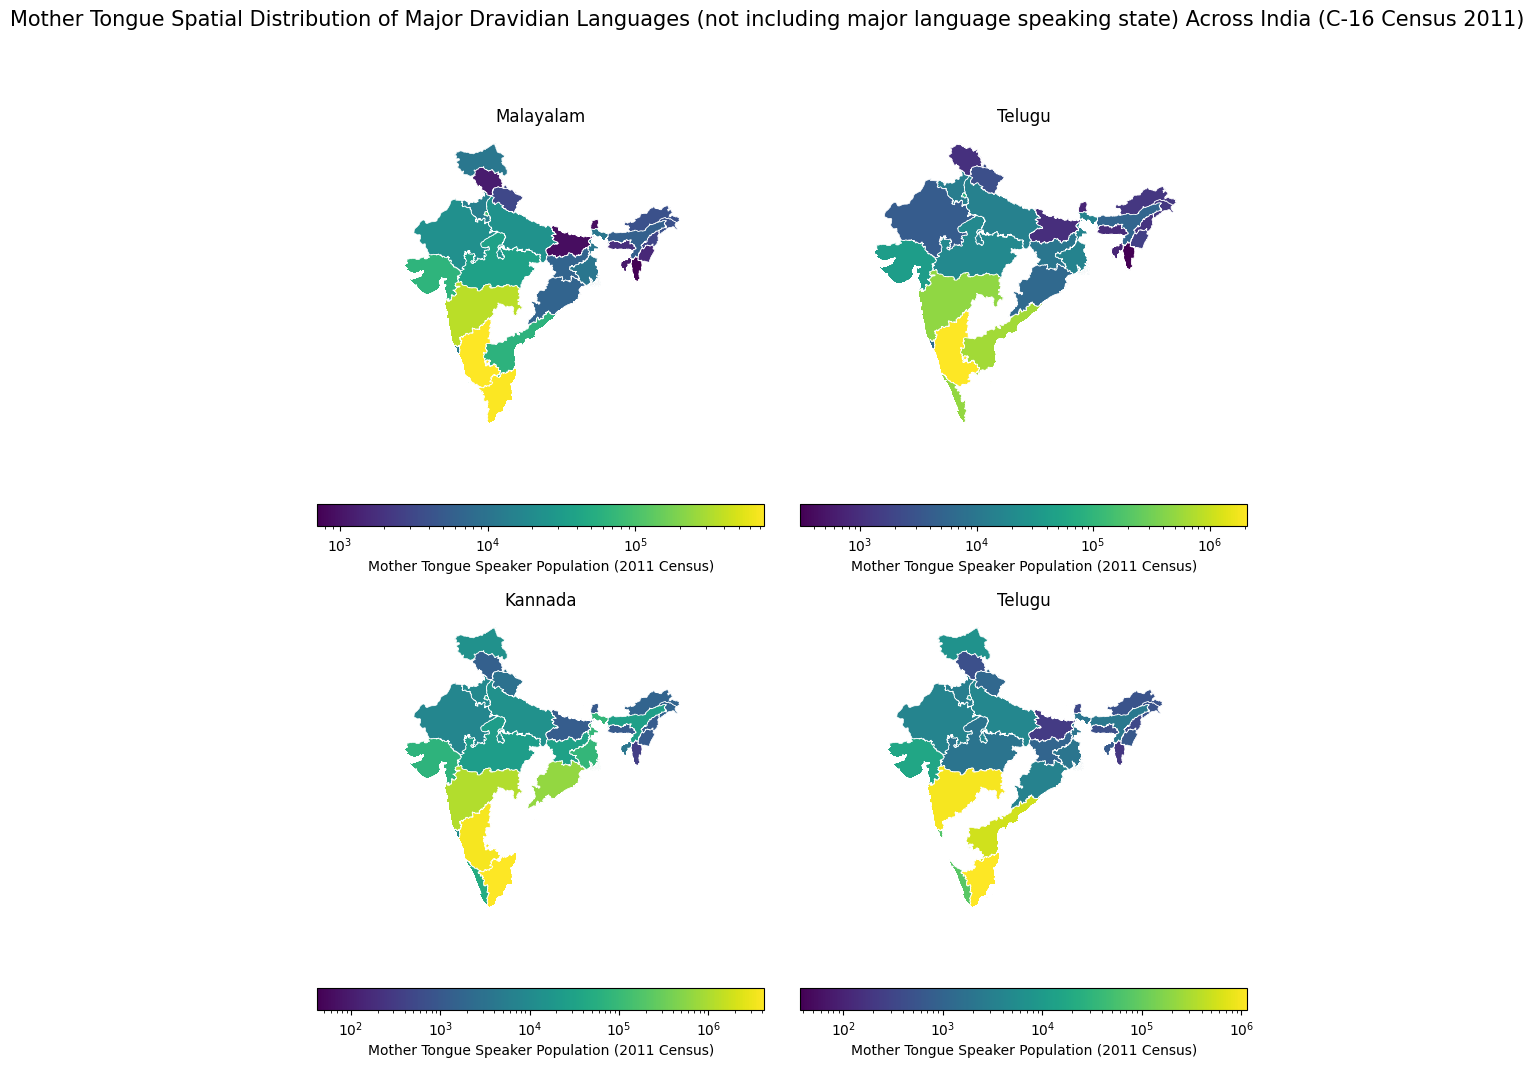

In [74]:
fig, ax = plt.subplots(2, 2, figsize=(12,12))

for map_data, title, subplot in zip(all_outside_maps, titles, ax.flatten()):
    
    map_data.plot(
        ax=subplot,
        column="Total_P",
        legend=True, 
        norm=LogNorm(),
        edgecolor="white",
        linewidth=0.5,
        legend_kwds={"label": "Mother Tongue Speaker Population (2011 Census)", "orientation": "horizontal"}
    
    );
    
    subplot.set_title(title);
    subplot.axis('off')

#print(type(graph))

fig.subplots_adjust(wspace=0.08, hspace=0.1)
fig.suptitle("Mother Tongue Spatial Distribution of Major Dravidian Languages (not including major language speaking state) Across India (C-16 Census 2011)", fontsize=15);

## adding a visual gradient

#cmap = cm.viridis
#cax = ax.

# add a ScalarMappable object 
#sm = cm.ScalarMappable(cmap=cmap)
#cbar = fig.colorbar(sm, orientation="horizontal", ax=ax, pad=0.05, ticks=None);
#cbar.set_ticks([0, 1], labels=['Low Concentration', 'High Concentration'])

#colorizer = mpl.colors.(cmap='viridis')